# 4. Aquitectura de la red 

- Se realiza la construcción de las **estructura de la red** siguiendo el enfoque de Yildiz et al. (2025)

:::{figure} ./images/EsquemaCapa.png
:alt: Estructura del modelo
:width: 90%
:align: center

Figura 2. Estructura del modelo ConvLSTM.
:::

## 4.1. Pasos

1. Se cargan los tensores de entrada y salida ya construidos
2. Se define la arquitectura de la red ConvLSTM
3. Se separan los datos en entrenamiento, validación y prueba con un criterio temporal
4. Entrenamiento del modelo, evaluación del desempeño y visualización de predicciones

El objetivo es aprender la relación:

**(t-1, t) → t+1**



## 4.2. Definición de la arquitectura

La arquitectura combina convoluciones espaciales con una capa `ConvLSTM2D`, que permite aprender cambios espacio-temporales entre los dos periodos de entrada.

- `TimeDistributed(Conv2D)`: extrae patrones espaciales en cada tiempo de entrada.
- `ConvLSTM2D`: integra la evolución temporal manteniendo la estructura espacial.
- `Conv2D` finales: refinan la salida píxel a píxel.
- Capa final lineal: predice valores continuos de profundidad/batimetría.
- Se decidieron eliminar las capas MaxPooling y Upsampling al menos temporalmente, ya que el test inicial de un solo fold quedó mejor sin ellas. 

:::{figure} ./images/EsquemaCapaMod.png
:alt: Estructura del modelo
:width: 90%
:align: center

Figura 3. Estructura del modelo ConvLSTM utilizado (sin capas MaxPooling y Upsampling).
:::

In [ ]:
from tensorflow.keras import layers, models

# Capa Input
inp = layers.Input(shape=input_shape)

# Capa Conv2D
x = layers.TimeDistributed(
    layers.Conv2D(96, (3, 3), activation="relu", padding="same")
)(inp)

# Capa MaxPooling
#x = layers.TimeDistributed(
    #layers.MaxPooling2D(pool_size=(2, 2))
#)(x)

# Capa ConvLSTM2D
x = layers.ConvLSTM2D(
    filters=48,
    kernel_size=(3, 3),
    activation="relu",
    recurrent_activation="sigmoid",
    padding="same",
    return_sequences=False
)(x)

# Capa MaxPooling
#x = layers.MaxPooling2D(pool_size=(2, 2))(x)

# Capa Conv2D
x = layers.Conv2D(48, (3, 3), activation="relu", padding="same")(x)

# Capa Upsampling
#x = layers.UpSampling2D(size=(2, 2))(x)

# Capa Conv2D
x = layers.Conv2D(96, (3, 3), activation="relu", padding="same")(x)

# Capa Upsampling
#x = layers.UpSampling2D(size=(2, 2))(x)

# Capa de salida
out = layers.Conv2D(1, (3, 3), activation="linear", padding="same")(x)

model = models.Model(inputs=inp, outputs=out)
model.summary()


## 4.3. Construcción del fold temporal del test

- `t_in_1`: primer periodo de entrada
- `t_in_2`: segundo periodo de entrada
- `t_out`: periodo objetivo
- `tile_id`: identificador espacial de la tesela

El fold se construye con la siguiente lógica temporal:

1. Se selecciona un periodo objetivo como test. Aquí se usa el último `t_out` disponible.
2. El test incluye **todas las teselas** cuyo `t_out` corresponde a ese periodo.
3. Para entrenar y validar, se excluyen todas las muestras que usen alguno de los tiempos del bloque de test.

Si el test es:

$$
[t_{in,1}^{test},\ t_{in,2}^{test}] \rightarrow t_{out}^{test}
$$

entonces se excluye de `train+val` cualquier muestra cuyo `t_in_1`, `t_in_2` o `t_out` toque alguno de esos tres tiempos.

## 4.4 Evaluación en test

Se carga el mejor modelo guardado y se predice exclusivamente sobre el fold de test

- **RMSE global**: error cuadrático medio sobre todos los píxeles y teselas.
- **MAE global**: error absoluto medio sobre todos los píxeles y teselas.

tile_id,t_in_1,t_in_2,t_out
r0000_c0000,2025-12,2026-01,2026-02
r0068_c0000,2025-12,2026-01,2026-02
r0136_c0000,2025-12,2026-01,2026-02
r0204_c0000,2025-12,2026-01,2026-02
r0272_c0000,2025-12,2026-01,2026-02
r0340_c0000,2025-12,2026-01,2026-02
r0408_c0000,2025-12,2026-01,2026-02


tile_id,t_out,rmse_tile,mae_tile
r0000_c0000,2026-02,0.525900,0.340000
r0068_c0000,2026-02,0.384400,0.286600
r0136_c0000,2026-02,0.641300,0.473300
r0204_c0000,2026-02,0.581400,0.450200
r0272_c0000,2026-02,0.620700,0.469300
r0340_c0000,2026-02,0.535100,0.377000
r0408_c0000,2026-02,0.618500,0.426700



Teselas disponibles en test: 7


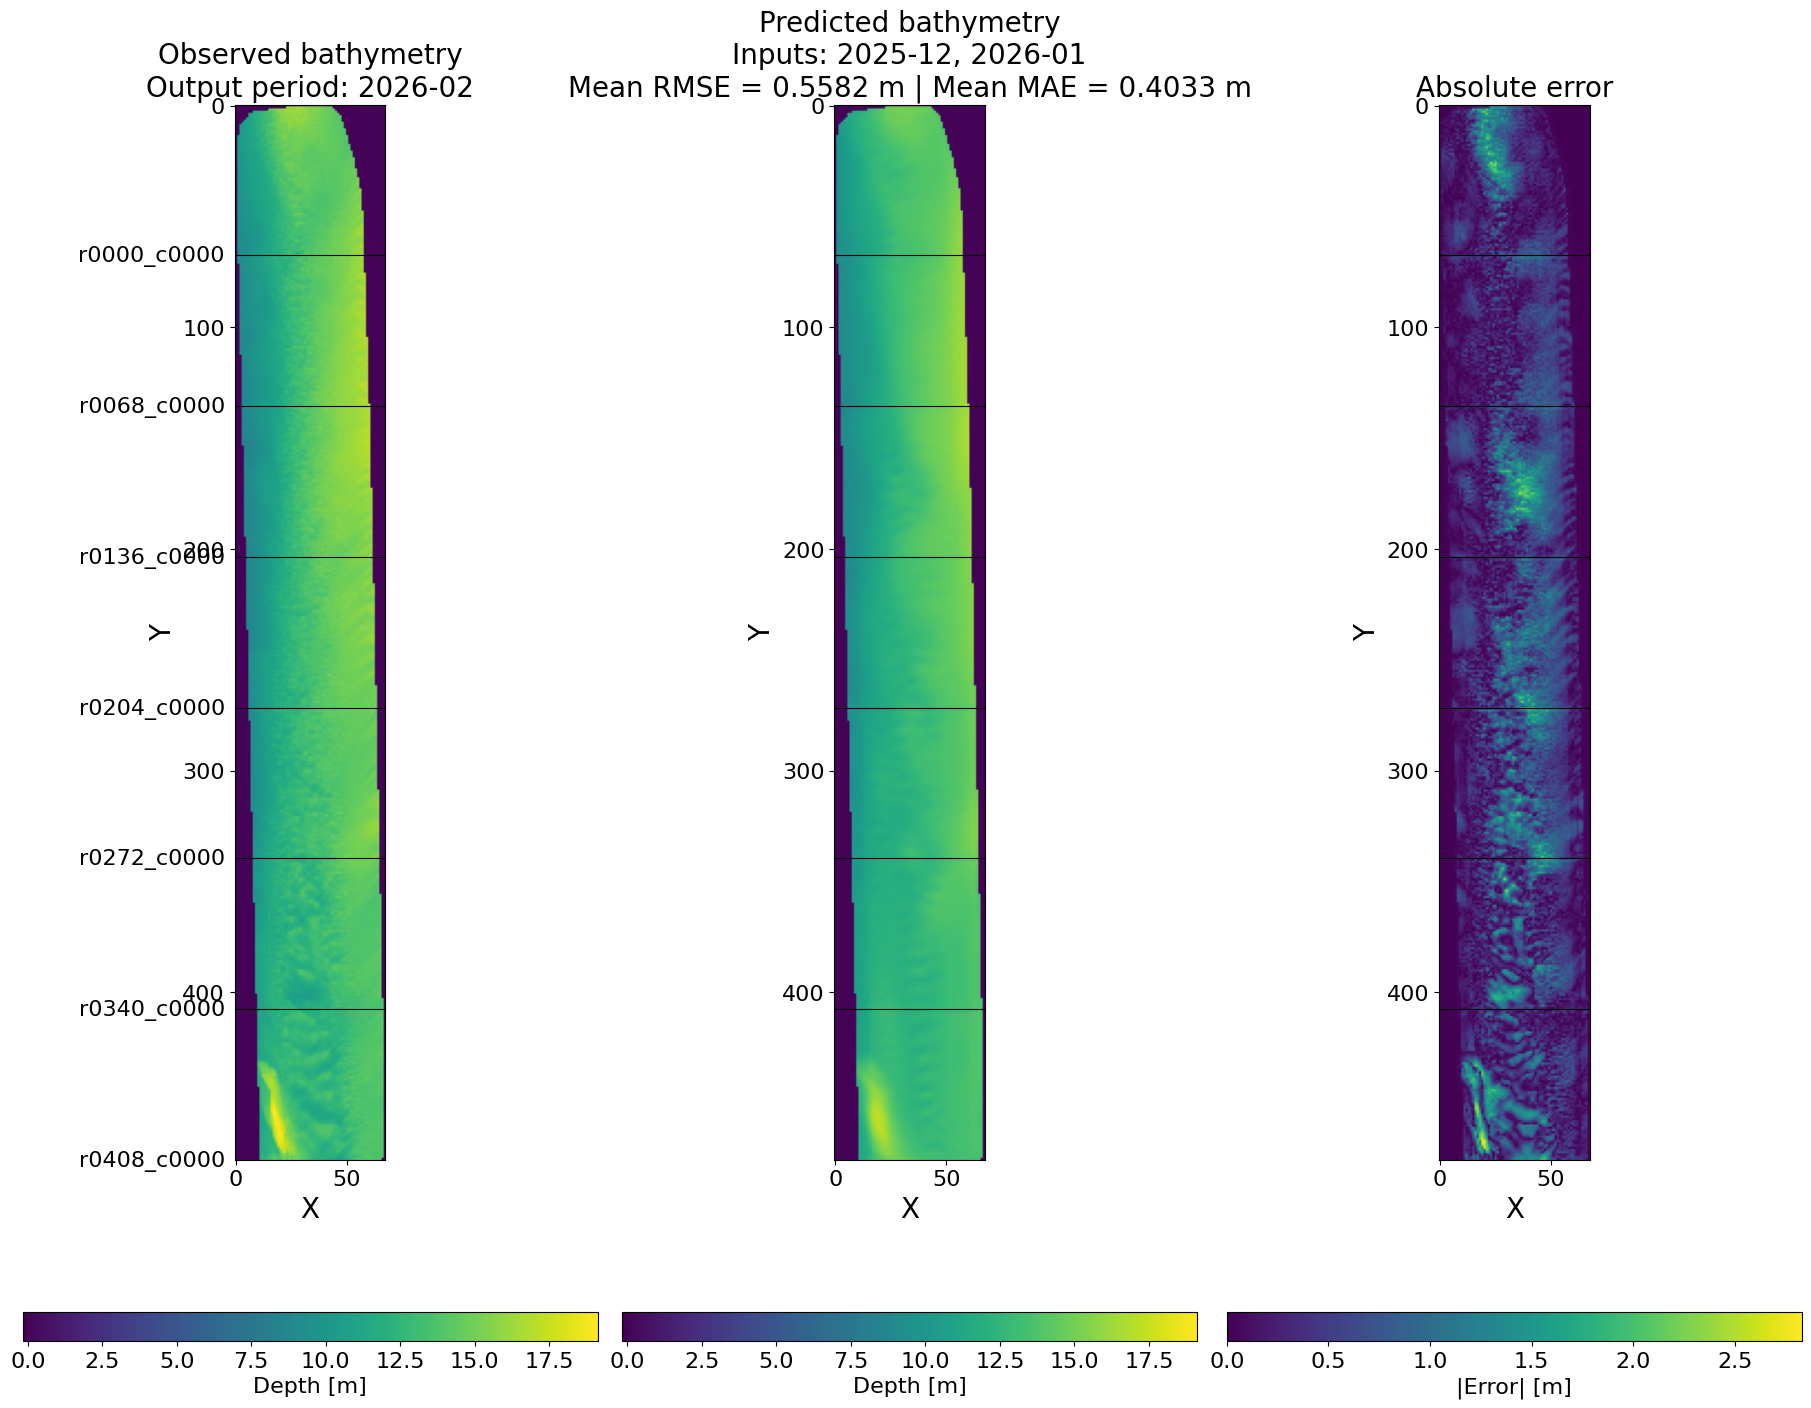

In [9]:
#%%

#%%

# GRAFICAR RESULTADOS 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SECTOR = "X6By5"
TILE_SIZE = 68
TIME_STEP = 2
TEST_TAG = "202602"

carpeta_modelo = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\{SECTOR}\4_Modelo_{SECTOR}"

ruta_pred_test_npz = os.path.join(
    carpeta_modelo,
    f"pred_test_{SECTOR}_{TILE_SIZE}x{TILE_SIZE}_ts{TIME_STEP}_{TEST_TAG}.npz"
)

ruta_pred_test_csv = os.path.join(
    carpeta_modelo,
    f"pred_test_{SECTOR}_{TILE_SIZE}x{TILE_SIZE}_ts{TIME_STEP}_{TEST_TAG}.csv"
)

# 1. LEER RESULTADOS GUARDADOS
data = np.load(ruta_pred_test_npz)
X_test = data["X_test"]
Y_test = data["Y_test"]
Y_pred_test = data["Y_pred_test"]

df_test = pd.read_csv(ruta_pred_test_csv)

display(
    df_test[["tile_id", "t_in_1", "t_in_2", "t_out"]]
    .head(10)
    .style
    .hide(axis="index")
    .set_caption("Metadata del conjunto de test")
)

display(
    df_test[["tile_id", "t_out", "rmse_tile", "mae_tile"]]
    .round(4)
    .style
    .hide(axis="index")
    .set_caption("Errores por tesela")
    .background_gradient(subset=["rmse_tile", "mae_tile"], cmap="RdYlGn_r")
)
carpeta_modelo = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\{SECTOR}\4_Modelo_{SECTOR}"

ruta_pred_test_npz = os.path.join(
    carpeta_modelo,
    f"pred_test_{SECTOR}_{TILE_SIZE}x{TILE_SIZE}_ts{TIME_STEP}_{TEST_TAG}.npz"
)

ruta_pred_test_csv = os.path.join(
    carpeta_modelo,
    f"pred_test_{SECTOR}_{TILE_SIZE}x{TILE_SIZE}_ts{TIME_STEP}_{TEST_TAG}.csv"
)


# 1. LEER RESULTADOS GUARDADOS
data = np.load(ruta_pred_test_npz)
X_test = data["X_test"]
Y_test = data["Y_test"]
Y_pred_test = data["Y_pred_test"]

df_test = pd.read_csv(ruta_pred_test_csv)


# 2. LIMITAR A LAS PRIMERAS 7 TESELAS DEL TEST
n_tiles_test = Y_test.shape[0]
n_plot = min(7, n_tiles_test)

print(f"\nTeselas disponibles en test: {n_tiles_test}")
#print(f"Teselas a unir verticalmente: {n_plot}")


# 3. EXTRAER LAS 7 TESELAS Y ARMAR MOSAICO VERTICAL
# Cada tesela tiene shape (68, 68)
# Al apilarlas verticalmente queda (7*68, 68)
obs_tiles = [Y_test[i, :, :, 0] for i in range(n_plot)]
pred_tiles = [Y_pred_test[i, :, :, 0] for i in range(n_plot)]

obs_mosaic = np.vstack(obs_tiles)
pred_mosaic = np.vstack(pred_tiles)
diff_mosaic = np.abs(pred_mosaic - obs_mosaic)

#print("\nShapes del mosaico:")
#print("obs_mosaic :", obs_mosaic.shape)
#print("pred_mosaic:", pred_mosaic.shape)
#print("diff_mosaic:", diff_mosaic.shape)


# 4. ESCALAS COMUNES
vmin = min(obs_mosaic.min(), pred_mosaic.min())
vmax = max(obs_mosaic.max(), pred_mosaic.max())
diff_max = diff_mosaic.max()

# 5. TEXTO AUXILIAR PARA TITULOS
tile_ids = df_test.loc[:n_plot-1, "tile_id"].tolist()
t_in_1_vals = df_test.loc[:n_plot-1, "t_in_1"].tolist()
t_in_2_vals = df_test.loc[:n_plot-1, "t_in_2"].tolist()
t_out_vals  = df_test.loc[:n_plot-1, "t_out"].tolist()

# Asumimos que para este test todas las teselas comparten el mismo periodo temporal
t_in_1_ref = t_in_1_vals[0]
t_in_2_ref = t_in_2_vals[0]
t_out_ref  = t_out_vals[0]

# Promedios de error sobre las teselas mostradas
rmse_mean = df_test.loc[:n_plot-1, "rmse_tile"].mean() if "rmse_tile" in df_test.columns else np.nan
mae_mean  = df_test.loc[:n_plot-1, "mae_tile"].mean() if "mae_tile" in df_test.columns else np.nan

# 6. GRAFICAR LOS 3 PANELES
plt.rcParams.update({
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})

fig, axes = plt.subplots(1, 3, figsize=(18, 14), constrained_layout=True)

# Panel 1: observado
im0 = axes[0].imshow(obs_mosaic, vmin=vmin, vmax=vmax, aspect="equal")
axes[0].set_title(f"Observed bathymetry\nOutput period: {t_out_ref}")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# Panel 2: predicho
im1 = axes[1].imshow(pred_mosaic, vmin=vmin, vmax=vmax, aspect="equal")
axes[1].set_title(
    f"Predicted bathymetry\nInputs: {t_in_1_ref}, {t_in_2_ref}\n"
    f"Mean RMSE = {rmse_mean:.4f} m | Mean MAE = {mae_mean:.4f} m"
)
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

# Panel 3: error absoluto
im2 = axes[2].imshow(diff_mosaic, vmin=0, vmax=diff_max, aspect="equal")
axes[2].set_title("Absolute error")
axes[2].set_xlabel("X")
axes[2].set_ylabel("Y")


# 7. MARCAR FRONTERAS ENTRE TESELAS
for ax in axes:
    for k in range(1, n_plot):
        ax.axhline(k * TILE_SIZE - 0.5, color="black", linewidth=0.8)


# 8. ETIQUETAS OPCIONALES DE TILE_ID EN EL PANEL IZQUIERDO
for i in range(n_plot):
    y_center = i * TILE_SIZE + TILE_SIZE
    axes[0].text(
        -5, y_center, tile_ids[i],
        va="center", ha="right", fontsize=16, clip_on=False
    )


# 9. BARRAS DE COLOR HORIZONTALES
cbar0 = fig.colorbar(
    im0, ax=axes[0], orientation="horizontal",
    fraction=0.05, pad=0.08
)
cbar0.set_label("Depth [m]", fontsize=16)
cbar0.ax.tick_params(labelsize=16)

cbar1 = fig.colorbar(
    im1, ax=axes[1], orientation="horizontal",
    fraction=0.05, pad=0.08
)
cbar1.set_label("Depth [m]", fontsize=16)
cbar1.ax.tick_params(labelsize=16)

cbar2 = fig.colorbar(
    im2, ax=axes[2], orientation="horizontal",
    fraction=0.05, pad=0.08
)
cbar2.set_label("|Error| [m]", fontsize=16)
cbar2.ax.tick_params(labelsize=16)

plt.show()

- Los **RMSE en validación** están alrededor de **0.78 m**, lo cual puede indicar que el pliegue tomado para **test** hace que los resultados sean más optimistas de lo real. 

- Aunque los datos de **validación** no se usan para actualizar directamente los **pesos y sesgos**, sí se usan durante el entrenamiento para escoger el **mejor modelo** mediante el menor `val_loss`. 

- Posteriormente, cuando se use **Optuna**, la validación también servirá para seleccionar los mejores **hiperparámetros**. 

- Tengo que decidir qué **hiperparámetros** cambiar primero: **tamaño del kernel**, **número de filtros**, **learning rate**, **beta 1**, **beta 2** y **funciones de activación**. 

- En **cross-validation**, por cada combinación de hiperparámetros y por cada pliegue se entrena un modelo distinto. Por cada combinación se obtiene un **RMSE promedio** calculado a partir de todos los pliegues escogidos. Este procedimiento conlleva un **alto costo computacional**.